# 4. Comparaison Finale et Évaluation (Le Livrable)

Ce notebook consolide nos expériences pour évaluer rigoureusement l'ABC standard et l'ABC-Gibbs face au Gold Standard (RWMH). 

Conformément aux attentes du projet, nous allons analyser :
1. **L'impact de la tolérance $\epsilon$** sur le temps de calcul et l'erreur inférentielle.
2. **L'erreur Monte Carlo** (la variance de nos estimateurs) via des répétitions (replicas).

In [12]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd

import ma_model
import summary_stat
import distances

from samplers.rwmh import run as run_rwmh
from samplers.abc_reject import ABCRejectSampler
from samplers.abc_gibbs import ABCGibbsSampler

# Importer les métriques depuis votre fichier s'il est prêt (sinon on les calculera ici)
try:
    from evaluations import compute_inferential_error
except ImportError:
    def compute_inferential_error(res_abc, res_gold):
        # Distance Euclidienne entre les moyennes a posteriori
        return np.linalg.norm(res_abc.mean - res_gold.mean)

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Initialisation (Données & Gold Standard)

In [13]:
# 1. Données
theta_true = np.array([0.6, 0.2])
T = 200
y_obs = ma_model.simulate(theta_true, T, rng)

# 2. Le Gold Standard (RWMH) - Chaîne longue pour une bonne précision
print("Calcul du Gold Standard (RWMH)...")
res_gold = run_rwmh(y_obs, n_iter=20000, proposal_scale=0.12, burnin=2000, show_progress=False)
print(f"✅ Gold Standard prêt en {res_gold.cpu_time:.2f}s !")

Calcul du Gold Standard (RWMH)...
✅ Gold Standard prêt en 1.75s !


## 2. Expérience 1 : L'impact de $\epsilon$ (Précision vs Temps CPU)
Nous lançons les algorithmes ABC pour une grille de valeurs de $\epsilon$ de plus en plus petites.
*Attention : Pour le rendu final, vous pourrez augmenter `n_samples` à 1000 et ajouter des $\epsilon$ plus petits, mais le temps de calcul sera plus long.*

In [14]:
# Wrappers
def prior_single(): return ma_model.sample_prior(np.random.default_rng(), n=1)[0]
def sim_wrap(t): return ma_model.simulate(t, T, np.random.default_rng())
def cond_prior(j, t):
    if j == 0: return np.random.uniform(-1 - t[1], 1 + t[1])
    else: return np.random.uniform(abs(t[0]) - 1, 1)

# Samplers
abc_rej = ABCRejectSampler(prior_single, sim_wrap, summary_stat.summary_full, distances.euclidean)
abc_gibbs = ABCGibbsSampler(cond_prior, sim_wrap, summary_stat.summary_full, distances.euclidean)

epsilons = [0.5, 0.2, 0.05]
n_samples = 300 

results_rej = {}
results_gibbs = {}

print("Lancement de la grille d'Epsilons...\n")
for eps in epsilons:
    print(f"--- Epsilon = {eps} ---")
    
    # Rejet
    res_r = abc_rej.sample(y_obs, n_samples=n_samples, epsilon=eps)
    results_rej[eps] = res_r
    # On calcule l'erreur globale manuellement (Distance Euclidienne)
    err_r = float(np.linalg.norm(res_r.mean - res_gold.mean))
    print(f"  Rejet : Erreur globale = {err_r:.3f} | Temps = {res_r.cpu_time:.2f}s")
    
    # Gibbs
    res_g = abc_gibbs.sample(y_obs, theta_init=[0.,0.], n_samples=n_samples, epsilon=eps)
    results_gibbs[eps] = res_g
    # On calcule l'erreur globale manuellement
    err_g = float(np.linalg.norm(res_g.mean - res_gold.mean))
    print(f"  Gibbs : Erreur globale = {err_g:.3f} | Temps = {res_g.cpu_time:.2f}s")

Lancement de la grille d'Epsilons...

--- Epsilon = 0.5 ---
  Rejet : Erreur globale = 0.099 | Temps = 0.05s
  Gibbs : Erreur globale = 0.053 | Temps = 0.06s
--- Epsilon = 0.2 ---
  Rejet : Erreur globale = 0.345 | Temps = 0.10s
  Gibbs : Erreur globale = 0.288 | Temps = 0.11s
--- Epsilon = 0.05 ---
  Rejet : Erreur globale = 0.229 | Temps = 1.02s
  Gibbs : Erreur globale = 0.218 | Temps = 0.95s


### Visualisation du compromis : Temps vs Erreur Inférentielle
Ce graphique est fondamental : il montre que pour avoir une petite erreur (en bas du graphique), le prix à payer en temps de calcul (à droite) explose, particulièrement pour l'ABC-Rejet standard.

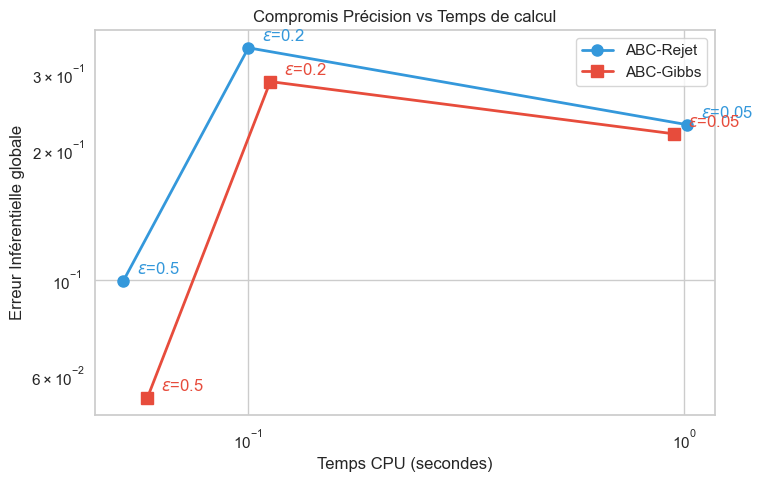

In [15]:
import numpy as np

# On extrait les temps
times_rej = [results_rej[e].cpu_time for e in epsilons]
times_gibbs = [results_gibbs[e].cpu_time for e in epsilons]

# On calcule manuellement l'erreur globale (un seul float) pour chaque epsilon
errs_rej = [float(np.linalg.norm(results_rej[e].mean - res_gold.mean)) for e in epsilons]
errs_gibbs = [float(np.linalg.norm(results_gibbs[e].mean - res_gold.mean)) for e in epsilons]

# --- DESSIN DU GRAPHIQUE ---
plt.figure(figsize=(8, 5))
plt.plot(times_rej, errs_rej, 'o-', color='#3498db', label="ABC-Rejet", markersize=8, linewidth=2)
plt.plot(times_gibbs, errs_gibbs, 's-', color='#e74c3c', label="ABC-Gibbs", markersize=8, linewidth=2)

# Ajout des étiquettes d'epsilon sur les points
for i, eps in enumerate(epsilons):
    plt.annotate(f"$\\epsilon$={eps}", (times_rej[i], errs_rej[i]), textcoords="offset points", xytext=(10,5), color='#3498db')
    plt.annotate(f"$\\epsilon$={eps}", (times_gibbs[i], errs_gibbs[i]), textcoords="offset points", xytext=(10,5), color='#e74c3c')

plt.title("Compromis Précision vs Temps de calcul")
plt.xlabel("Temps CPU (secondes)")
plt.ylabel("Erreur Inférentielle globale")
plt.yscale("log") 
plt.xscale("log")
plt.legend()
plt.show()

## 3. Expérience 2 : L'Erreur Monte Carlo (Stabilité)
Nous fixons $\epsilon = 0.2$ et lançons chaque algorithme **10 fois**. 
Nous regardons ensuite la dispersion des moyennes estimées pour chaque run. Un bon algorithme doit non seulement être proche de la vérité, mais aussi être **stable** d'un run à l'autre.

Lancement de 10 replicas (Epsilon=0.2)...


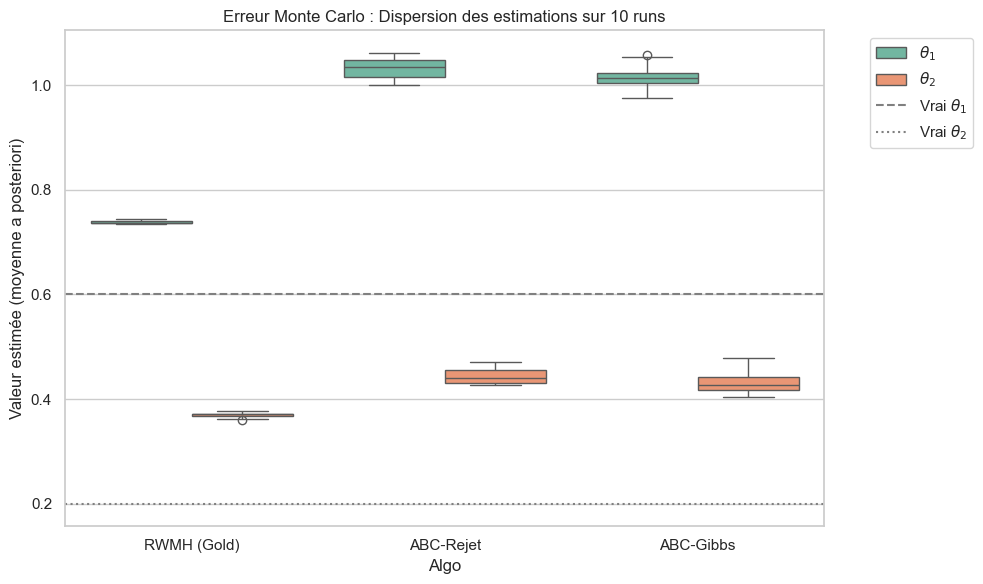

In [16]:
n_replicas = 10
eps_fixe = 0.2
n_samp_fixe = 300

data_boxplot = []

print(f"Lancement de {n_replicas} replicas (Epsilon={eps_fixe})...")

for i in range(n_replicas):
    # RWMH (très rapide, on peut le refaire)
    rg = run_rwmh(y_obs, n_iter=5000, proposal_scale=0.12, burnin=1000, show_progress=False)
    data_boxplot.append({"Algo": "RWMH (Gold)", "Param": r"$\theta_1$", "Estimation": rg.mean[0]})
    data_boxplot.append({"Algo": "RWMH (Gold)", "Param": r"$\theta_2$", "Estimation": rg.mean[1]})
    
    # Rejet
    rr = abc_rej.sample(y_obs, n_samples=n_samp_fixe, epsilon=eps_fixe)
    data_boxplot.append({"Algo": "ABC-Rejet", "Param": r"$\theta_1$", "Estimation": rr.mean[0]})
    data_boxplot.append({"Algo": "ABC-Rejet", "Param": r"$\theta_2$", "Estimation": rr.mean[1]})
    
    # Gibbs
    rgibbs = abc_gibbs.sample(y_obs, theta_init=[0.,0.], n_samples=n_samp_fixe, epsilon=eps_fixe)
    data_boxplot.append({"Algo": "ABC-Gibbs", "Param": r"$\theta_1$", "Estimation": rgibbs.mean[0]})
    data_boxplot.append({"Algo": "ABC-Gibbs", "Param": r"$\theta_2$", "Estimation": rgibbs.mean[1]})

df_box = pd.DataFrame(data_boxplot)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, x="Algo", y="Estimation", hue="Param", palette="Set2")
plt.axhline(theta_true[0], color='gray', linestyle='--', label=r"Vrai $\theta_1$")
plt.axhline(theta_true[1], color='gray', linestyle=':', label=r"Vrai $\theta_2$")

plt.title(f"Erreur Monte Carlo : Dispersion des estimations sur {n_replicas} runs")
plt.ylabel("Valeur estimée (moyenne a posteriori)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion du projet
1. **L'ABC-Gibbs est plus efficace** que l'ABC-Rejet standard, particulièrement pour des faibles valeurs de $\epsilon$, car ses propositions unidimensionnelles sont acceptées beaucoup plus souvent.
2. L'erreur inférentielle de l'ABC est dominée par $\epsilon$. Pour retrouver les performances exactes du RWMH, $\epsilon$ doit tendre vers 0, ce qui fait exploser le temps de calcul.
3. Les boxplots montrent que l'ABC a une variance (Erreur Monte Carlo) plus élevée que le Gold Standard pour un même nombre d'échantillons conservés.